In [ ]:
import tensorflow as tf

print("Num GPUs Available: ", len(tf.config.list_physical_devices("GPU")))

In [33]:
import tensorflow as tf
from keras.layers import Conv2D, ZeroPadding2D, Activation, Input, Dropout, Add
from keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from keras.layers import LayerNormalization
from keras.layers import BatchNormalization
from keras.layers import MaxPooling2D, AveragePooling2D
from keras.layers import Flatten, Dense
from tensorflow.keras.utils import to_categorical
#from keras.initializers import glorot_uniform
from keras import backend as K

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

%matplotlib inline

In [9]:
import cv2
import os


def load_images(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename))
        if img is not None:
            img = cv2.resize(img, (80, 80))
            images.append(img)

    return np.array(images)

In [11]:
mal_aca = load_images("colon_image_sets/colon_aca")
benign = load_images("colon_image_sets/colon_n")

In [12]:
print(
    f"Number of images for every class: BENIGN {benign.shape[0]}, ADENOCARCINOMAS {mal_aca.shape[0]}."
)
print(f"Images shape: {benign[0].shape}.")

Number of images for every class: BENIGN 5000, ADENOCARCINOMAS 5000.
Images shape: (80, 80, 3).


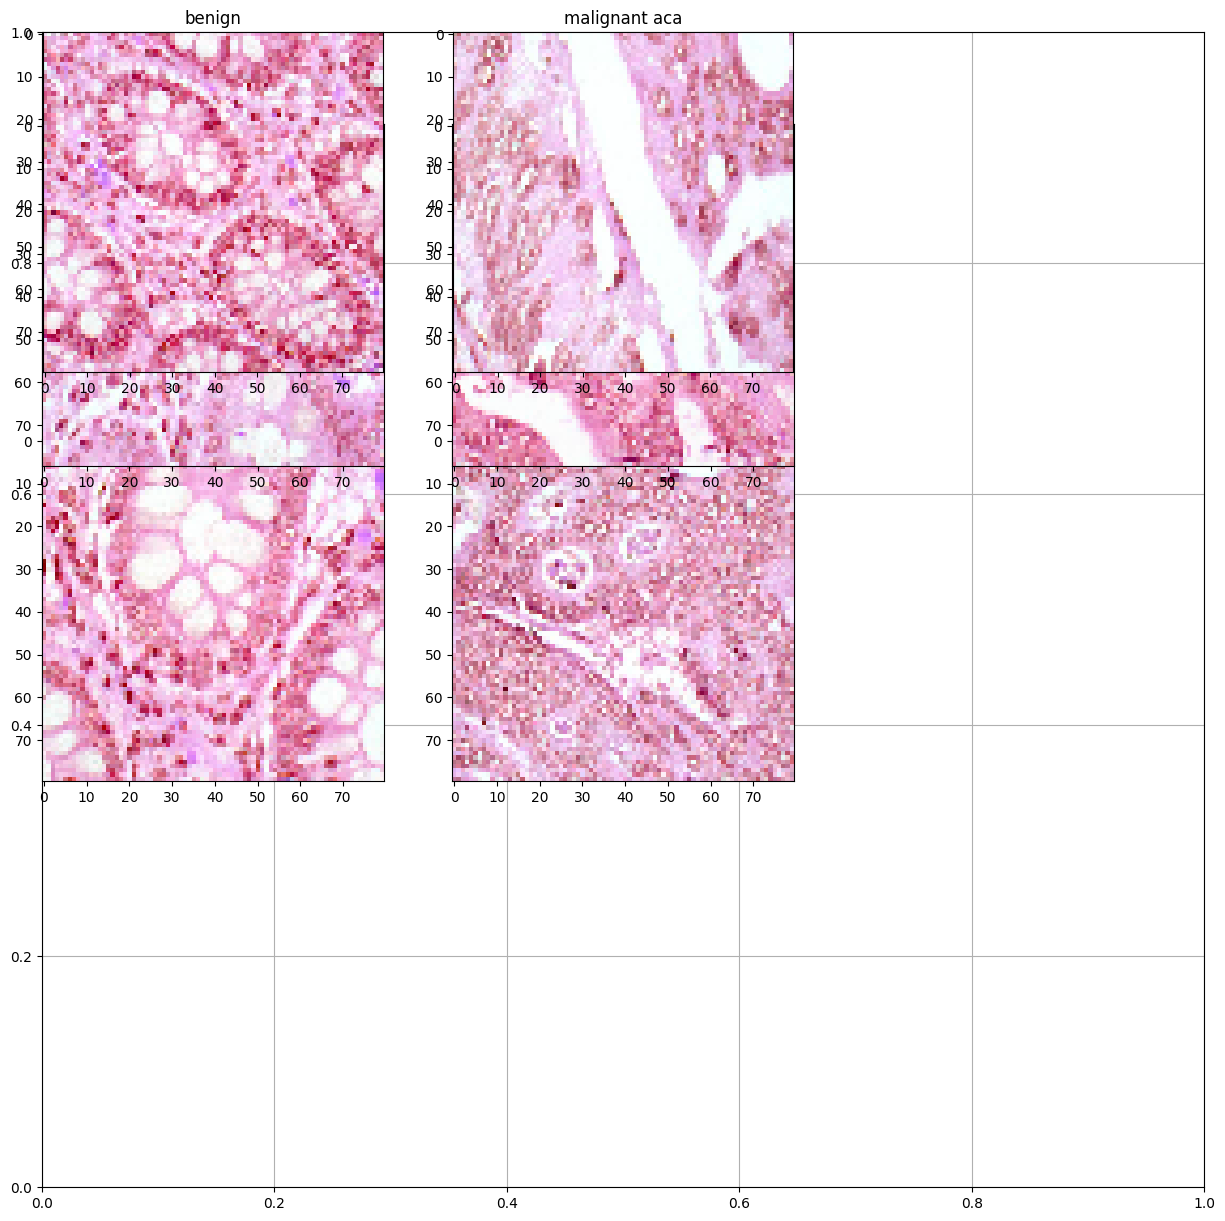

In [16]:
indices = [0, 40, 2300]

plt.figure(1, figsize=(15, 15))
plt.grid(None)

for n, idx in enumerate(indices):
    plt.subplot(n + 1, 3, 1)
    plt.imshow(benign[idx])
    plt.title("benign")
    plt.subplot(n + 1, 3, 2)
    plt.imshow(mal_aca[idx])
    plt.title("malignant aca")

plt.show()

In [17]:
samples = np.concatenate((benign, mal_aca))
labels = np.array(benign.shape[0] * [0] + mal_aca.shape[0] * [1])

In [18]:
print(f"Samples shape check: {samples.shape}.")
print(f"Labels shape check: {labels.shape}.")

Samples shape check: (10000, 80, 80, 3).
Labels shape check: (10000,).


In [19]:
indices = np.arange(samples.shape[0])
np.random.shuffle(indices)

samples = samples[indices]
labels = labels[indices]

# normalize pictures
samples = samples.astype("float32") / 255

In [20]:
import sklearn as sk
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(samples, labels, test_size=0.2)

X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5)

In [22]:
Y_train = to_categorical(y_train, 3)
Y_val = to_categorical(y_val, 3)
Y_test = to_categorical(y_test, 3)

In [23]:
def base_model(input_shape=(80, 80, 3), classes=3):
    inputs = Input(shape=input_shape)

    X = Conv2D(32, 3, 3, activation="relu")(inputs)
    X = MaxPooling2D(pool_size=(2, 2))(X)

    X = Conv2D(64, 3, 3, activation="relu")(X)
    X = MaxPooling2D(pool_size=(2, 2))(X)
    X = Dropout(0.2)(X)

    X = Conv2D(128, 3, 3, activation="relu", padding="same")(X)
    X = MaxPooling2D(pool_size=(2, 2), padding="same")(X)
    X = Dropout(0.2)(X)

    X = Flatten()(X)
    X = Dense(256, activation="relu")(X)
    outputs = Dense(classes, activation="softmax")(X)

    model = Model(inputs, outputs)

    return model

In [24]:
model = base_model(input_shape=(80, 80, 3), classes=3)
model.summary()

I0000 00:00:1724310977.882926    4432 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1724310977.885647    4432 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1724310977.887139    4432 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1724310978.066999    4432 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 80, 80, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 1, 1, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,043 (496.26 KB)

 Trainable params: 127,043 (496.26 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [28]:
history = model.fit(
    X_train, Y_train, batch_size=64, epochs=25, validation_data=(X_val, Y_val)
)

2024-08-22 13:38:40.898673: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.


Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9748 - loss: 0.0614 - val_accuracy: 0.9650 - val_loss: 0.0968
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9744 - loss: 0.0672 - val_accuracy: 0.9630 - val_loss: 0.1017
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9814 - loss: 0.0525 - val_accuracy: 0.9580 - val_loss: 0.1034
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9783 - loss: 0.0584 - val_accuracy: 0.9490 - val_loss: 0.1270
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9732 - loss: 0.0666 - val_accuracy: 0.9620 - val_loss: 0.1107
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9737 - loss: 0.0710 - val_accuracy: 0.9570 - val_loss: 0.1060
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9787 - loss: 0.0537 - val_accuracy: 0.9640 - val_loss: 0.0942
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9812 - loss: 0.0532 - val_accuracy: 0.

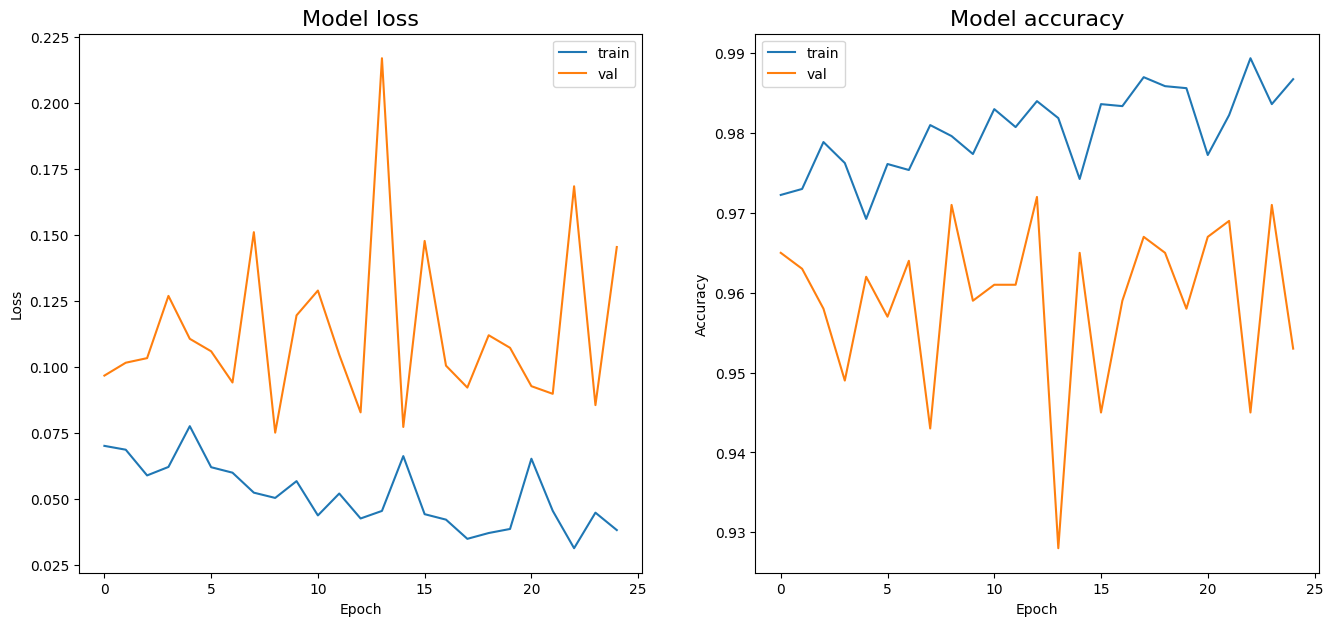

In [34]:
plt.figure(figsize=(16, 7))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model loss", fontsize=16)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["train", "val"])

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model accuracy", fontsize=16)
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["train", "val"])

plt.show()

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sn

In [36]:
y_pred_test = model.predict(X_test, verbose=1)
y_pred_train = model.predict(X_train, verbose=1)

# conversion to one hot encoding
# y_pred_test = (y_pred_test > 0.5).astype("int32")
# y_pred_train = (y_pred_train > 0.5).astype("int32")

# convert it to numerical classes
y_pred_test = np.argmax(y_pred_test, axis=1)
y_pred_train = np.argmax(y_pred_train, axis=1)

score_test = model.evaluate(X_test, Y_test)
print(f"Train accuracy: {history.history['accuracy'][-1]:.3f}")
print(f"Validation accuracy: {history.history['val_accuracy'][-1]:.3f}")
print(f"Test accuracy: {score_test[1]:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9233 - loss: 0.1965
Train accuracy: 0.987
Validation accuracy: 0.953
Test accuracy: 0.925


<Axes: >

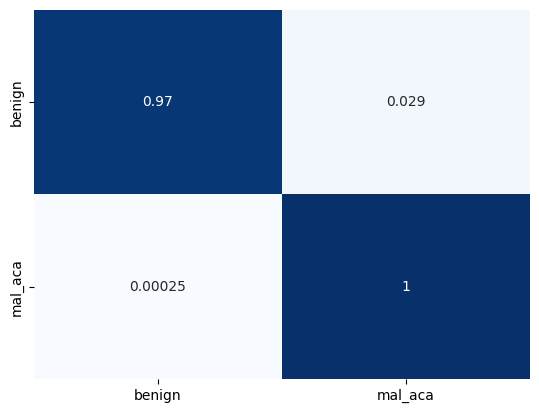

In [37]:
label_names = ["benign", "mal_aca"]

confmat = confusion_matrix(y_train, y_pred_train, normalize="true")
sn.heatmap(
    confmat,
    annot=True,
    cmap="Blues",
    cbar=False,
    xticklabels=label_names,
    yticklabels=label_names,
)

# Wrongly classified samples


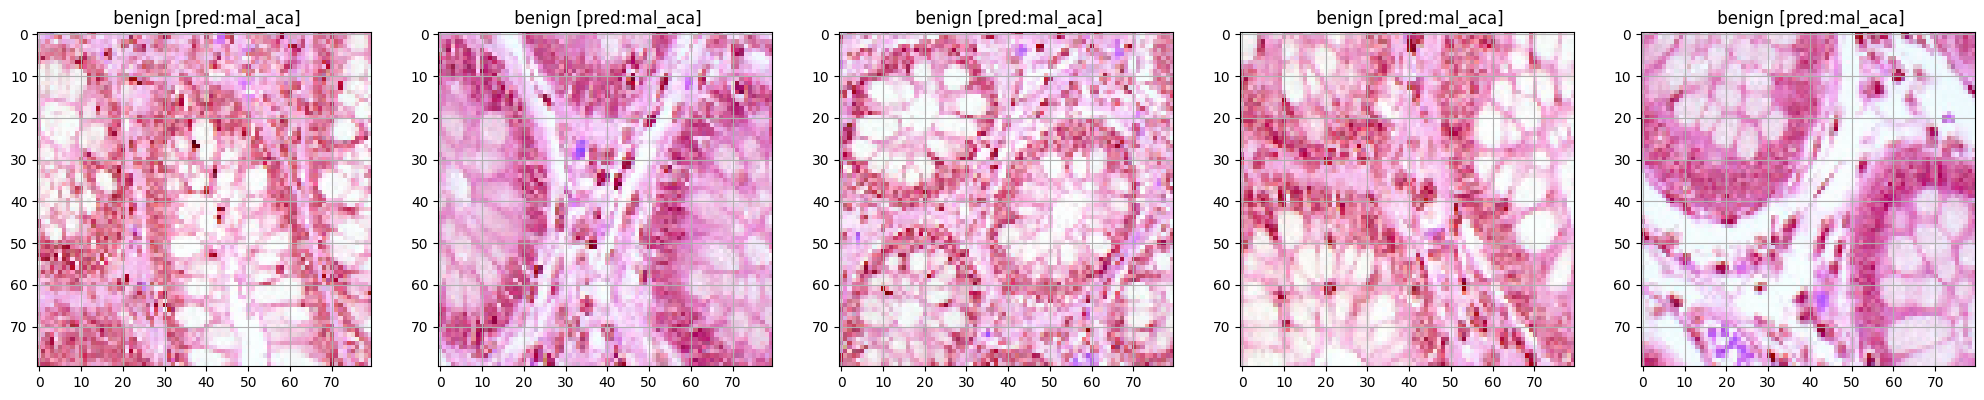

In [38]:
mistakes = np.where(y_pred_train != y_train)[0]

n = 5

plt.figure(figsize=(5 * n, 5))

# get 5 random false negatives
for i, val in enumerate(np.random.choice(mistakes, n)):

    plt.subplot(1, n, i + 1)
    plt.imshow(X_train[val])
    plt.title(
        f" {label_names[y_train[val]]} [pred:{label_names[y_pred_train[val]]}]",
        fontsize=12,
    )
    plt.grid(None)

# ResNet50


In [39]:
def identity_block(X, f, filters, stage, block):
    """
    Implementation of the identity block

    Arguments:
    X -- input tensor of shape (m, n_H_prev, n_W_prev, n_C_prev)
    f -- integer, specifying the shape of the middle CONV's window for the main path
    filters -- python list of integers, defining the number of filters in the CONV layers of the main path
    stage -- integer, used to name the layers, depending on their position in the network
    block -- string/character, used to name the layers, depending on their position in the network

    """

    # defining name basis
    conv_name_base = "res" + str(stage) + block + "_branch"
    bn_name_base = "bn" + str(stage) + block + "_branch"

    F1, F2, F3 = filters

    X_shortcut = X

    X = Conv2D(
        filters=F1,
        kernel_size=(1, 1),
        strides=(1, 1),
        padding="valid",
        name=conv_name_base + "2a",
        kernel_initializer=glorot_uniform(seed=0),
    )(X)
    X = BatchNormalization(axis=3, name=bn_name_base + "2a")(X)
    X = Activation("relu")(X)

    X = Conv2D(
        filters=F2,
        kernel_size=(f, f),
        strides=(1, 1),
        padding="same",
        name=conv_name_base + "2b",
        kernel_initializer=glorot_uniform(seed=0),
    )(X)
    X = BatchNormalization(axis=3, name=bn_name_base + "2b")(X)
    X = Activation("relu")(X)

    X = Conv2D(
        filters=F3,
        kernel_size=(1, 1),
        strides=(1, 1),
        padding="valid",
        name=conv_name_base + "2c",
        kernel_initializer=glorot_uniform(seed=0),
    )(X)
    X = BatchNormalization(axis=3, name=bn_name_base + "2c")(X)

    X = Add()([X, X_shortcut])
    X = Activation("relu")(X)

    return X

In [40]:
def convolutional_block(X, f, filters, stage, block, s=2):
    """
    Implementation of the convolutional block

    Arguments:
    X -- input tensor of shape (m, n_H_prev, n_W_prev, n_C_prev)
    f -- integer, specifying the shape of the middle CONV's window for the main path
    filters -- python list of integers, defining the number of filters in the CONV layers of the main path
    stage -- integer, used to name the layers, depending on their position in the network
    block -- string/character, used to name the layers, depending on their position in the network
    s -- Integer, specifying the stride to be used

    """

    # defining name basis
    conv_name_base = "res" + str(stage) + block + "_branch"
    bn_name_base = "bn" + str(stage) + block + "_branch"

    F1, F2, F3 = filters

    X_shortcut = X

    X = Conv2D(
        F1,
        (1, 1),
        strides=(s, s),
        name=conv_name_base + "2a",
        kernel_initializer=glorot_uniform(seed=0),
    )(X)
    X = BatchNormalization(axis=3, name=bn_name_base + "2a")(X)
    X = Activation("relu")(X)

    X = Conv2D(
        F2,
        (f, f),
        strides=(1, 1),
        padding="same",
        name=conv_name_base + "2b",
        kernel_initializer=glorot_uniform(seed=0),
    )(X)
    X = BatchNormalization(axis=3, name=bn_name_base + "2b")(X)
    X = Activation("relu")(X)

    X = Conv2D(
        F3,
        (1, 1),
        strides=(1, 1),
        padding="valid",
        name=conv_name_base + "2c",
        kernel_initializer=glorot_uniform(seed=0),
    )(X)
    X = BatchNormalization(axis=3, name=bn_name_base + "2c")(X)

    X_shortcut = Conv2D(
        F3,
        (1, 1),
        strides=(s, s),
        padding="valid",
        name=conv_name_base + "1",
        kernel_initializer=glorot_uniform(seed=0),
    )(X_shortcut)
    X_shortcut = BatchNormalization(axis=3, name=bn_name_base + "1")(X_shortcut)

    X = Add()([X, X_shortcut])
    X = Activation("relu")(X)

    return X

In [41]:
def ResNet50(input_shape=(80, 80, 3), classes=3):
    """
    Implementation of the popular ResNet50 the following architecture:
    CONV2D -> BATCHNORM -> RELU -> MAXPOOL -> CONVBLOCK -> IDBLOCK*2 -> CONVBLOCK -> IDBLOCK*3
    -> CONVBLOCK -> IDBLOCK*5 -> CONVBLOCK -> IDBLOCK*2 -> AVGPOOL -> TOPLAYER

    """

    X_input = Input(input_shape)

    X = ZeroPadding2D((3, 3))(X_input)

    X = Conv2D(
        64,
        (7, 7),
        strides=(2, 2),
        name="conv1",
        kernel_initializer=glorot_uniform(seed=0),
    )(X)
    X = BatchNormalization(axis=3, name="bn_conv1")(X)
    X = Activation("relu")(X)
    X = MaxPooling2D((3, 3), strides=(2, 2))(X)

    X = convolutional_block(X, f=3, filters=[64, 64, 256], stage=2, block="a", s=1)
    X = identity_block(X, 3, [64, 64, 256], stage=2, block="b")
    X = identity_block(X, 3, [64, 64, 256], stage=2, block="c")

    X = convolutional_block(X, 3, [128, 128, 512], stage=3, s=2, block="a")
    X = identity_block(X, 3, [128, 128, 512], stage=3, block="b")
    X = identity_block(X, 3, [128, 128, 512], stage=3, block="c")
    X = identity_block(X, 3, [128, 128, 512], stage=3, block="d")

    X = convolutional_block(X, 3, [256, 256, 1024], stage=4, s=2, block="a")
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block="b")
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block="c")
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block="d")
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block="e")

    X = convolutional_block(X, 3, [512, 512, 2048], stage=5, s=2, block="a")
    X = identity_block(X, 3, [512, 512, 2048], stage=5, block="b")
    X = identity_block(X, 3, [512, 512, 2048], stage=5, block="c")

    X = AveragePooling2D(pool_size=(2, 2), name="avg_pool")(X)

    # output layer
    X = Flatten()(X)
    X = Dense(
        classes,
        activation="softmax",
        name="fc" + str(classes),
        kernel_initializer=glorot_uniform(seed=0),
    )(X)

    # Create model
    model = Model(inputs=X_input, outputs=X, name="ResNet50")

    return model

In [42]:
from keras.initializers import glorot_uniform

resmodel = ResNet50(input_shape=(80, 80, 3), classes=3)

In [43]:
resmodel.summary()

Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 80, 80, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 86, 86, 3) │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 40, 40,    │      9,472 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv1            │ (None, 40, 40,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 40, 40,    │          0 │ bn_conv1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 19, 19,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch2a      │ (None, 19, 19,    │      4,160 │ max_pooling2d_3[… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch2a       │ (None, 19, 19,    │        256 │ res2a_branch2a[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 19, 19,    │          0 │ bn2a_branch2a[0]… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch2b      │ (None, 19, 19,    │     36,928 │ activation_1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch2b       │ (None, 19, 19,    │        256 │ res2a_branch2b[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 19, 19,    │          0 │ bn2a_branch2b[0]… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch2c      │ (None, 19, 19,    │     16,640 │ activation_2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch1       │ (None, 19, 19,    │     16,640 │ max_pooling2d_3[… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch2c       │ (None, 19, 19,    │      1,024 │ res2a_branch2c[0… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch1        │ (None, 19, 19,    │      1,024 │ res2a_branch1[0]… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 19, 19,    │          0 │ bn2a_branch2c[0]

 Total params: 22,472,067 (85.72 MB)

 Trainable params: 22,422,019 (85.53 MB)

 Non-trainable params: 50,048 (195.50 KB)

In [45]:
resmodel.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)

In [46]:
resmodel.fit(X_train, Y_train, batch_size=64, epochs=10, validation_data=(X_val, Y_val))

Epoch 1/10


2024-08-22 13:50:42.232716: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 18.37GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2024-08-22 13:50:42.309007: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.61GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2024-08-22 13:50:42.737566: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.69GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


125/125 ━━━━━━━━━━━━━━━━━━━━ 71s 180ms/step - accuracy: 0.7573 - loss: 1.4948 - val_accuracy: 0.5140 - val_loss: 3.8840
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 127ms/step - accuracy: 0.9665 - loss: 0.0834 - val_accuracy: 0.5140 - val_loss: 4.4579
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 126ms/step - accuracy: 0.9854 - loss: 0.0333 - val_accuracy: 0.5140 - val_loss: 7.3649
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 126ms/step - accuracy: 0.9949 - loss: 0.0149 - val_accuracy: 0.5200 - val_loss: 4.1653
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 126ms/step - accuracy: 0.9891 - loss: 0.0318 - val_accuracy: 0.9430 - val_loss: 0.2159
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 126ms/step - accuracy: 0.9962 - loss: 0.0101 - val_accuracy: 0.5140 - val_loss: 3.2881
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 126ms/step - accuracy: 0.9968 - loss: 0.0105 - val_accuracy: 0.7910 - val_loss: 0.9289
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 126ms/step - accuracy: 0.9975 - loss: 0.0086 - val